# Interpretable Machine Learning Framework for Loan Default Risk Prediction in Financial Systems

### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/loan_default_project

/content/drive/MyDrive/loan_default_project


In [ ]:
!unzip /content/drive/MyDrive/LendingDataset.zip

Archive:  /content/drive/MyDrive/LendingDataset.zip
replace accepted_2007_to_2018Q4.csv.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: acceted_2007_to_2018Q41.csv.gz
error:  invalid response [acceted_2]
replace accepted_2007_to_2018Q4.csv.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [007_to_20]
replace accepted_2007_to_2018Q4.csv.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [18Q41.csv]
replace accepted_2007_to_2018Q4.csv.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [.gz]
replace accepted_2007_to_2018Q4.csv.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: accepted_2007_to_2018Q4.csv.gz  
  inflating: accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv  
  inflating: rejected_2007_to_2018Q4.csv.gz  
  inflating: rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv  


In [ ]:
!ls

accepted_2007_to_2018q4.csv	loan_default_model.pkl
accepted_2007_to_2018Q4.csv.gz	rejected_2007_to_2018q4.csv
graphs				rejected_2007_to_2018Q4.csv.gz
LendingDataset.zip


# Environment Setup

In [ ]:
!pip install xgboost shap imbalanced-learn

# Create Project Directory Structure

In [ ]:
import os

project_path = "/content/loan_default_project"
graph_path = project_path + "/graphs"

os.makedirs(graph_path, exist_ok=True)

print("Project folders created successfully")

Project folders created successfully


# Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from imblearn.over_sampling import SMOTE

import shap
import joblib

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

sns.set_context("talk")
sns.set_palette("deep")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["font.size"] = 12

# Load Lending Club Dataset



In [ ]:
import pandas as pd

cols = [
'loan_amnt','term','int_rate','annual_inc',
'emp_length','home_ownership','purpose',
'dti','revol_bal','revol_util','fico_range_high','loan_status'
]

df = pd.read_csv(
"accepted_2007_to_2018Q4.csv.gz",
compression="gzip",
usecols=cols,
nrows=50000
)

print(df.shape)
df.head()

(50000, 12)


,loan_amnt,term,int_rate,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,fico_range_high,revol_bal,revol_util
0,3600.0,36 months,13.99,10+ years,MORTGAGE,55000.0,Fully Paid,debt_consolidation,5.91,679.0,2765.0,29.7
1,24700.0,36 months,11.99,10+ years,MORTGAGE,65000.0,Fully Paid,small_business,16.06,719.0,21470.0,19.2
2,20000.0,60 months,10.78,10+ years,MORTGAGE,63000.0,Fully Paid,home_improvement,10.78,699.0,7869.0,56.2
3,35000.0,60 months,14.85,10+ years,MORTGAGE,110000.0,Current,debt_consolidation,17.06,789.0,7802.0,11.6
4,10400.0,60 months,22.45,3 years,MORTGAGE,104433.0,Fully Paid,major_purchase,25.37,699.0,21929.0,64.5


# Convert Target Variable

In [ ]:


df['loan_status'] = df['loan_status'].map({
'Fully Paid':0,
'Charged Off':1
})

df['loan_status'].value_counts()

,count
loan_status,
0.0,34978
1.0,9027


# Data Cleaning & Encoding

In [ ]:
df.dropna(inplace=True)

le = LabelEncoder()

df['term'] = le.fit_transform(df['term'])
df['emp_length'] = le.fit_transform(df['emp_length'])
df['home_ownership'] = le.fit_transform(df['home_ownership'])
df['purpose'] = le.fit_transform(df['purpose'])

# Save Processed Dataset


In [ ]:
df.to_csv(project_path + "/processed_dataset.csv", index=False)

print("Processed dataset saved")

Processed dataset saved


In [ ]:
import os

project_path = "/content/drive/MyDrive/loan_default_project"
graph_path = project_path + "/graphs"

os.makedirs(graph_path, exist_ok=True)

print("Drive project folder ready")

Drive project folder ready


# Default Distribution Graph

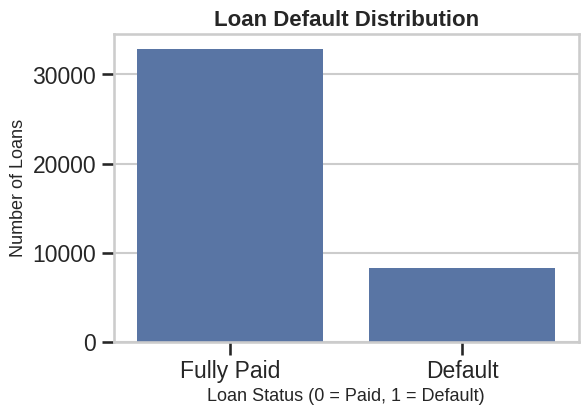

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='loan_status', data=df)

plt.title("Loan Default Distribution", fontweight='bold')
plt.xlabel("Loan Status (0 = Paid, 1 = Default)")
plt.ylabel("Number of Loans")

plt.xticks([0,1], ["Fully Paid","Default"])

plt.savefig(graph_path + "/default_distribution.png", dpi=300)

plt.show()

# Correlation Heatmap

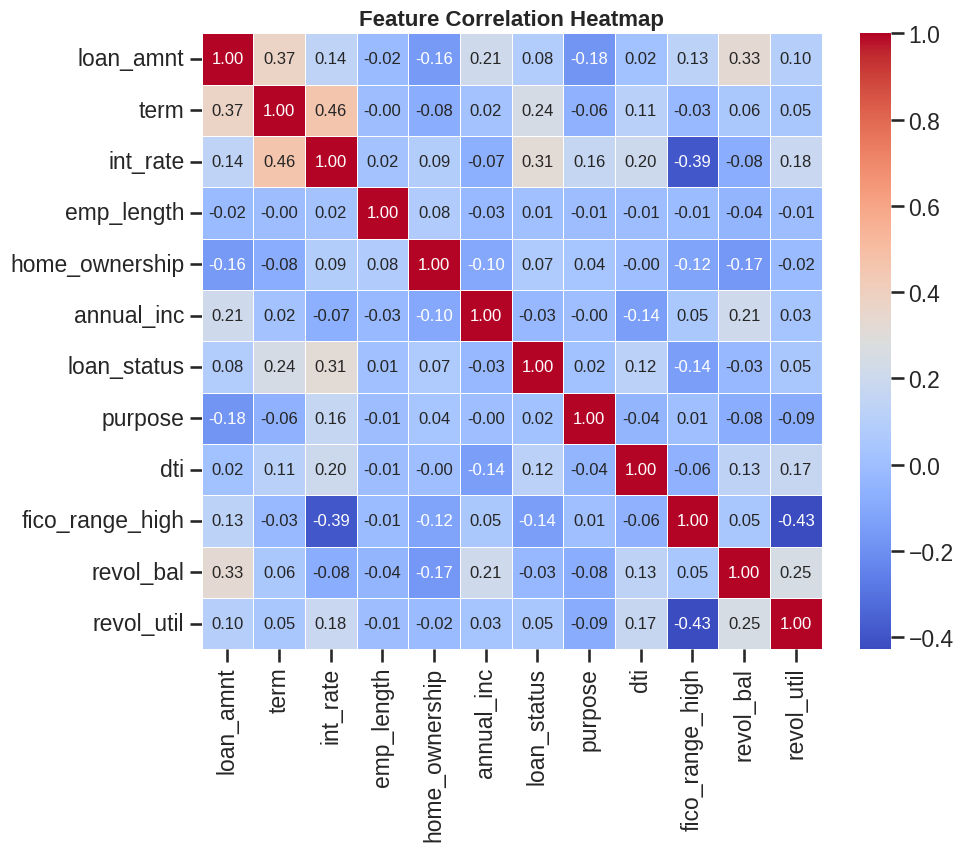

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
df.corr(),
annot=True,
cmap="coolwarm",
fmt=".2f",
linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontweight='bold')

plt.savefig(graph_path + "/correlation_heatmap.png", dpi=300)

plt.show()

# Prepare Machine Learning Dataset

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# Handle Class Imbalance

In [ ]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

# Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Train Machine Learning Models
1. Logistic Regression

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

2. Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

3. XGBoost

In [ ]:
xgb = XGBClassifier(
n_estimators=300,
max_depth=6,
learning_rate=0.05
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

# Model Evaluation

In [ ]:
models = {
"Logistic Regression": lr,
"Random Forest": rf,
"XGBoost": xgb
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    print(name)

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("ROC AUC:", roc_auc_score(y_test, y_pred))

    print(confusion_matrix(y_test, y_pred))

    print(classification_report(y_test, y_pred))

    print("---------------------")

Logistic Regression
Accuracy: 0.6722862340812614
ROC AUC: 0.6466520500654072
[[4550 2051]
 [ 651  993]]
              precision    recall  f1-score   support

         0.0       0.87      0.69      0.77      6601
         1.0       0.33      0.60      0.42      1644

    accuracy                           0.67      8245
   macro avg       0.60      0.65      0.60      8245
weighted avg       0.77      0.67      0.70      8245

---------------------
Random Forest
Accuracy: 0.7537901758641601
ROC AUC: 0.601629563978915
[[5642  959]
 [1071  573]]
              precision    recall  f1-score   support

         0.0       0.84      0.85      0.85      6601
         1.0       0.37      0.35      0.36      1644

    accuracy                           0.75      8245
   macro avg       0.61      0.60      0.60      8245
weighted avg       0.75      0.75      0.75      8245

---------------------
XGBoost
Accuracy: 0.7853244390539721
ROC AUC: 0.5879785872596904
[[6048  553]
 [1217  427]]
         

# ROC Curve

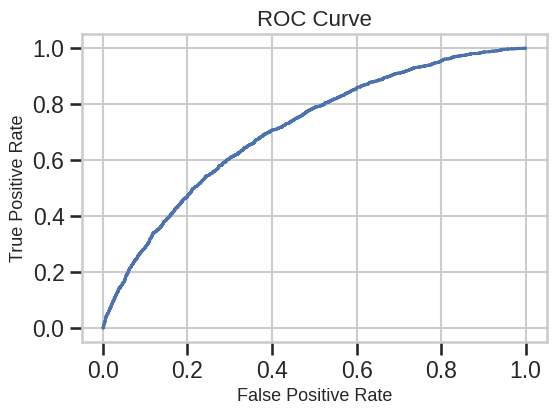

In [ ]:
y_prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.savefig(graph_path + "/roc_curve.png")

plt.show()

# Feature Importance

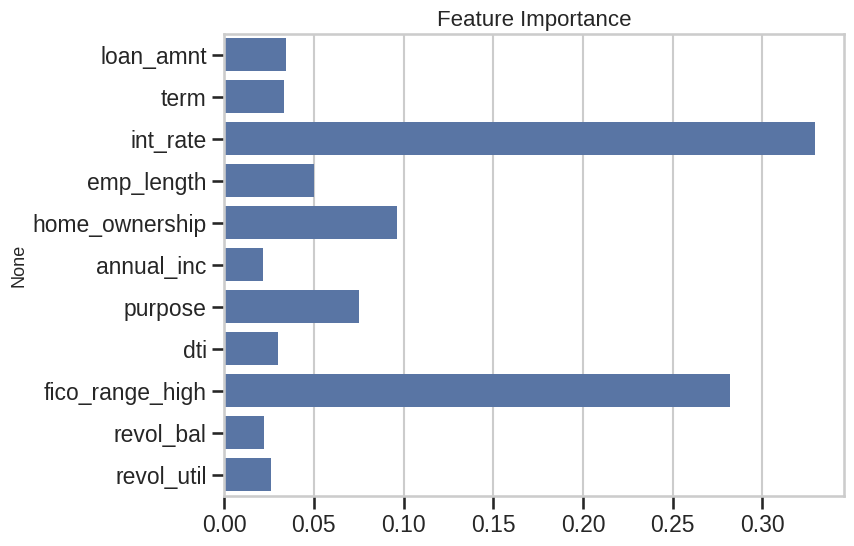

In [ ]:
importances = xgb.feature_importances_

feature_names = X.columns

plt.figure(figsize=(8,6))

sns.barplot(x=importances, y=feature_names)

plt.title("Feature Importance")

plt.savefig(graph_path + "/feature_importance.png")

plt.show()

# Explainable AI with SHAP

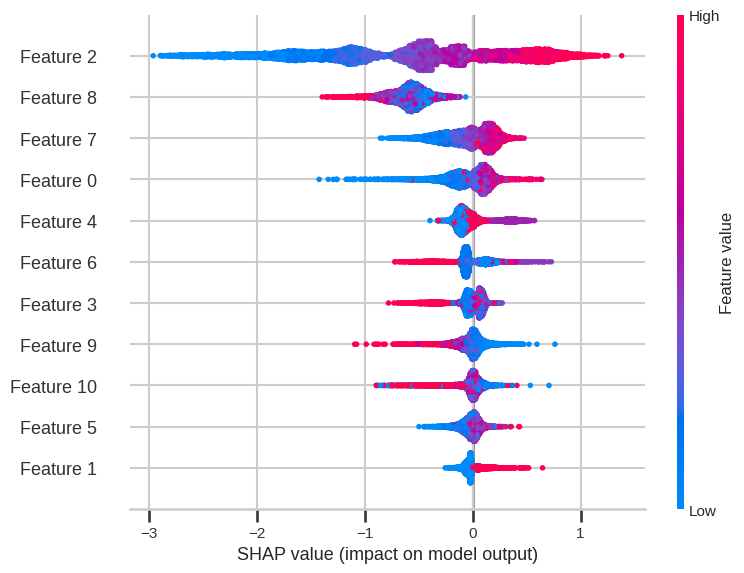

In [ ]:
explainer = shap.Explainer(xgb)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, show=False)

plt.savefig(graph_path + "/shap_summary.png", bbox_inches='tight')

plt.show()

# Save Trained Model

In [ ]:
joblib.dump(xgb, project_path + "/loan_default_model.pkl")

print("Model saved successfully")

Model saved successfully


# Example Prediction

In [ ]:
model = joblib.load(project_path + "/loan_default_model.pkl")

sample = X_test[0:1]

prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


# Final Performance Summary

In [ ]:
print("Best Model: XGBoost")

print("Accuracy:", accuracy_score(y_test, xgb.predict(X_test)))

print("ROC AUC:", roc_auc_score(y_test, xgb.predict(X_test)))

Best Model: XGBoost
Accuracy: 0.7853244390539721
ROC AUC: 0.5879785872596904


In [ ]:
!ls /content/drive/MyDrive/loan_default_project/graphs

correlation_heatmap.png   feature_importance.png  shap_summary.png
default_distribution.png  roc_curve.png


In [ ]:
from IPython.display import Image, display

display(Image("/content/drive/MyDrive/loan_default_project/graphs/default_distribution.png"))
display(Image("/content/drive/MyDrive/loan_default_project/graphs/correlation_heatmap.png"))
display(Image("/content/drive/MyDrive/loan_default_project/graphs/feature_importance.png"))
display(Image("/content/drive/MyDrive/loan_default_project/graphs/roc_curve.png"))
display(Image("/content/drive/MyDrive/loan_default_project/graphs/shap_summary.png"))

In [ ]:
%cd /content/drive/MyDrive/loan_default_project

/content/drive/MyDrive/loan_default_project
